# Handwritten Digit Recognition using Deep Learning
### Dataset: MNIST | Models: ANN · Basic CNN · Improved CNN

---
**Problem:** Classify handwritten digits (0–9) from 28×28 grayscale images using three deep learning models of increasing complexity.

| | |
|---|---|
| **Dataset** | MNIST — 70,000 images, 10 digit classes |
| **Model 1** | ANN (Dense layers only) |
| **Model 2** | Basic CNN |
| **Model 3** | Improved CNN with BatchNorm + Dropout |
| **Framework** | TensorFlow / Keras |


## 1. Setup & Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix, classification_report

print(f"TensorFlow : {tf.__version__}")
print(f"GPU available : {len(tf.config.list_physical_devices('GPU')) > 0}")


TensorFlow : 2.19.0
GPU available : True


## 2. Load & Explore the Dataset

In [3]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"Labels: {np.unique(y_train)} (digits 0–9)")
print(f"Pixel range: [{X_train.min()}, {X_train.max()}]")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train : (60000, 28, 28)  |  Test : (10000, 28, 28)
Labels: [0 1 2 3 4 5 6 7 8 9] (digits 0–9)
Pixel range: [0, 255]


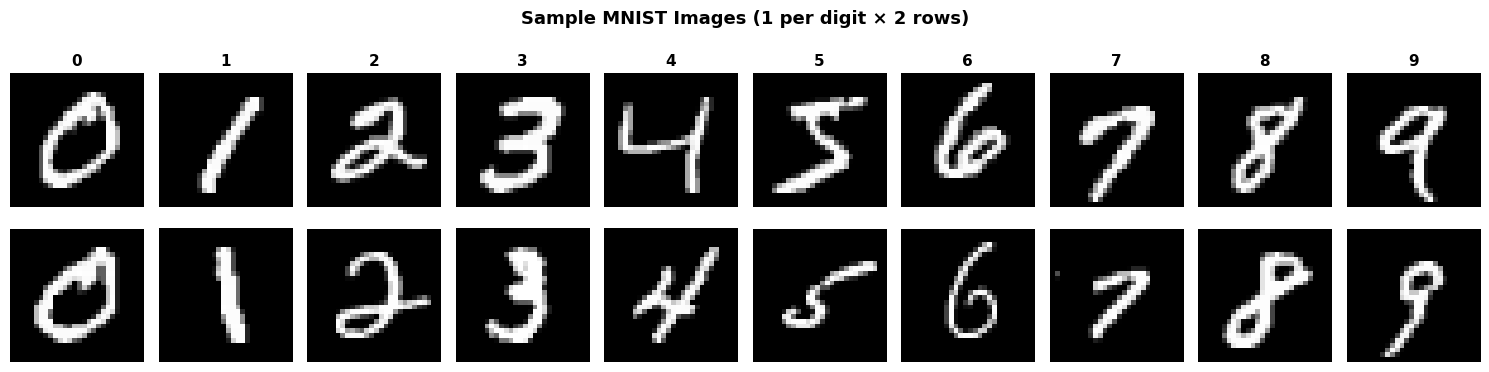

In [4]:
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
fig.suptitle("Sample MNIST Images (1 per digit × 2 rows)", fontsize=13, fontweight='bold')

for digit in range(10):
    indices = np.where(y_train == digit)[0]
    for row in range(2):
        axes[row, digit].imshow(X_train[indices[row]], cmap='gray')
        axes[row, digit].axis('off')
        if row == 0:
            axes[row, digit].set_title(str(digit), fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('mnist_samples.png', dpi=120, bbox_inches='tight')
plt.show()


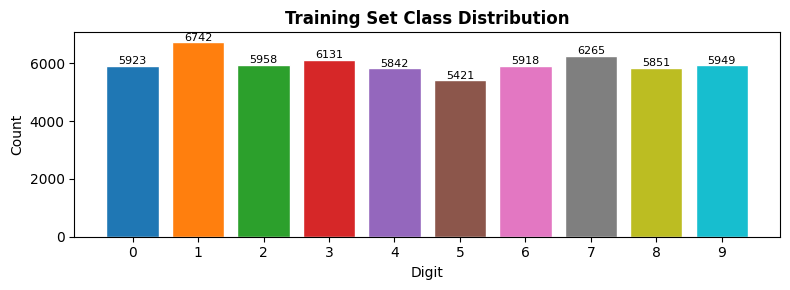

Dataset is nearly balanced (~6,000 samples per class)


In [5]:
fig, ax = plt.subplots(figsize=(8, 3))
unique, counts = np.unique(y_train, return_counts=True)
bars = ax.bar(unique, counts, color=plt.cm.tab10(np.linspace(0,1,10)), edgecolor='white')
ax.set_title('Training Set Class Distribution', fontweight='bold')
ax.set_xlabel('Digit')
ax.set_ylabel('Count')
ax.set_xticks(range(10))
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(c), ha='center', fontsize=8)
plt.tight_layout()
plt.show()
print("Dataset is nearly balanced (~6,000 samples per class)")


## 3. Preprocessing

In [6]:
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm  = X_test.astype('float32')  / 255.0

X_train_flat = X_train_norm.reshape(-1, 784)
X_test_flat  = X_test_norm.reshape(-1, 784)

X_train_cnn = X_train_norm[..., np.newaxis]
X_test_cnn  = X_test_norm[...,  np.newaxis]

y_train_oh = to_categorical(y_train, 10)
y_test_oh  = to_categorical(y_test,  10)

print(f"ANN input shape : {X_train_flat.shape}")
print(f"CNN input shape : {X_train_cnn.shape}")
print(f"Label shape     : {y_train_oh.shape}")


ANN input shape : (60000, 784)
CNN input shape : (60000, 28, 28, 1)
Label shape     : (60000, 10)


## 4. Helper Functions

In [7]:
def plot_history(history, title, color):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'{title} — Training History', fontsize=12, fontweight='bold')

    ax1.plot(history.history['accuracy'],     color=color, lw=2, label='Train')
    ax1.plot(history.history['val_accuracy'], color='red', lw=2, ls='--', label='Val')
    ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(history.history['loss'],     color=color, lw=2, label='Train')
    ax2.plot(history.history['val_loss'], color='red', lw=2, ls='--', label='Val')
    ax2.set_title('Loss'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    best = max(history.history['val_accuracy'])
    print(f"  Best Val Accuracy: {best*100:.2f}%")


def evaluate_model(model, X_test, y_test_oh, name):
    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    y_true = np.argmax(y_test_oh, axis=1)
    acc = (y_pred == y_true).mean()

    print(f"\n{'─'*45}")
    print(f"  {name}")
    print(f"  Test Accuracy : {acc*100:.2f}%")
    print(f"{'─'*45}")
    print(classification_report(y_true, y_pred, digits=3))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=range(10), yticklabels=range(10))
    ax.set_title(f'{name}\nConfusion Matrix (Test Acc: {acc*100:.2f}%)', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.tight_layout()
    plt.show()

    return acc

print("Helper functions ready ✅")


Helper functions ready ✅


## 5. Model 1 — ANN (Artificial Neural Network)

A **fully connected network** with no convolutional layers. Treats each pixel as an independent input feature.



In [8]:
model1 = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
], name='ANN')

model1.summary()


Model: "ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history1 = model1.fit(
    X_train_flat, y_train_oh,
    epochs=30, batch_size=128,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True, verbose=1)],
    verbose=1
)


Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8745 - loss: 0.4159 - val_accuracy: 0.9652 - val_loss: 0.1213
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9473 - loss: 0.1775 - val_accuracy: 0.9732 - val_loss: 0.0895
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9603 - loss: 0.1301 - val_accuracy: 0.9753 - val_loss: 0.0789
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9676 - loss: 0.1076 - val_accuracy: 0.9790 - val_loss: 0.0738
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9721 - loss: 0.0913 - val_accuracy: 0.9802 - val_loss: 0.0697
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9758 - loss: 0.0782 - val_accuracy: 0.9782 - val_loss: 0.0700
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9777 - loss: 0.0710 - val_accuracy: 0.9825 - val_loss: 0.0670
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9800 - loss: 0.0641 - val_accuracy: 0.

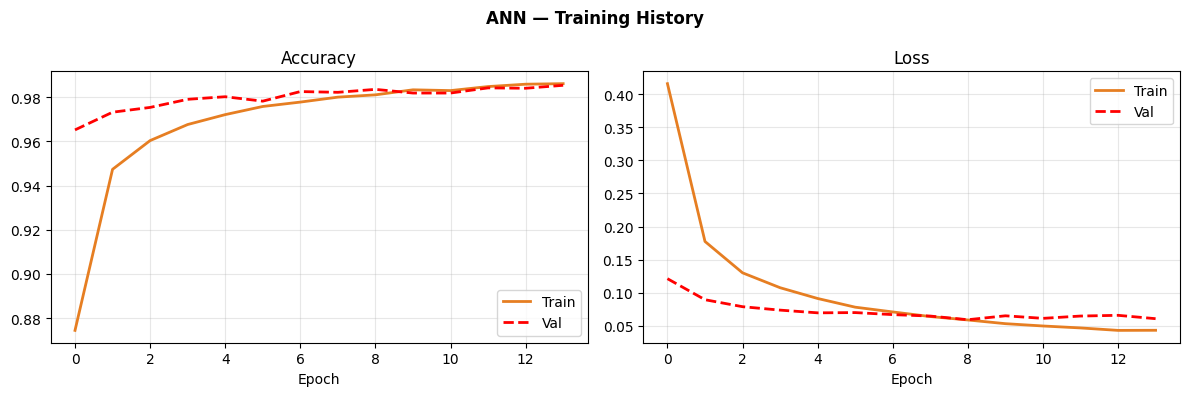

  Best Val Accuracy: 98.53%

─────────────────────────────────────────────
  ANN
  Test Accuracy : 98.35%
─────────────────────────────────────────────
              precision    recall  f1-score   support

           0      0.988     0.992     0.990       980
           1      0.992     0.990     0.991      1135
           2      0.978     0.986     0.982      1032
           3      0.985     0.984     0.985      1010
           4      0.978     0.984     0.981       982
           5      0.988     0.981     0.984       892
           6      0.983     0.986     0.985       958
           7      0.981     0.975     0.978      1028
           8      0.979     0.985     0.982       974
           9      0.983     0.971     0.977      1009

    accuracy                          0.984     10000
   macro avg      0.983     0.983     0.983     10000
weighted avg      0.984     0.984     0.983     10000



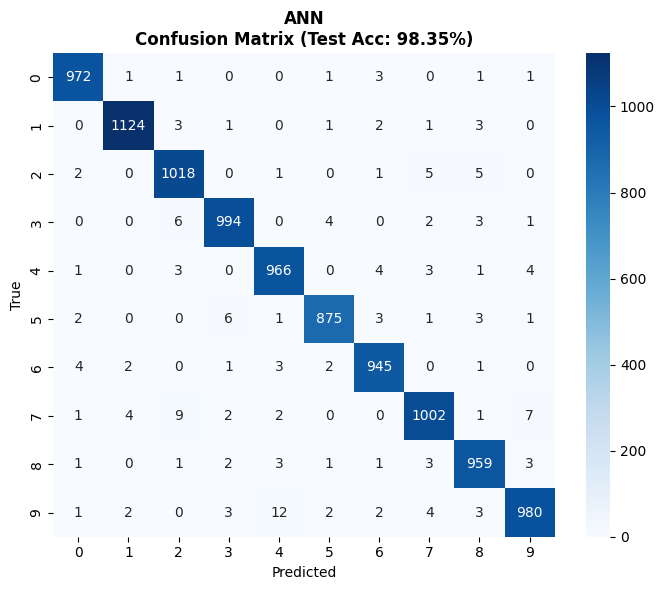

In [10]:
plot_history(history1, 'ANN', '#e67e22')
acc1 = evaluate_model(model1, X_test_flat, y_test_oh, 'ANN')


## 6. Model 2 — Basic CNN

Adds **convolutional layers** that learn spatial patterns (edges, curves) before the dense head.



In [11]:
model2 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name='Basic_CNN')

model2.summary()


Model: "Basic_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history2 = model2.fit(
    X_train_cnn, y_train_oh,
    epochs=30, batch_size=128,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True, verbose=1)],
    verbose=1
)


Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9039 - loss: 0.3126 - val_accuracy: 0.9833 - val_loss: 0.0585
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9707 - loss: 0.1005 - val_accuracy: 0.9897 - val_loss: 0.0420
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9788 - loss: 0.0739 - val_accuracy: 0.9898 - val_loss: 0.0377
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9822 - loss: 0.0586 - val_accuracy: 0.9897 - val_loss: 0.0345
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9839 - loss: 0.0517 - val_accuracy: 0.9898 - val_loss: 0.0338
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9869 - loss: 0.0429 - val_accuracy: 0.9913 - val_loss: 0.0310
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9882 - loss: 0.0378 - val_accuracy: 0.9930 - val_loss: 0.0276
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9892 - loss: 0.0332 - val_accuracy: 

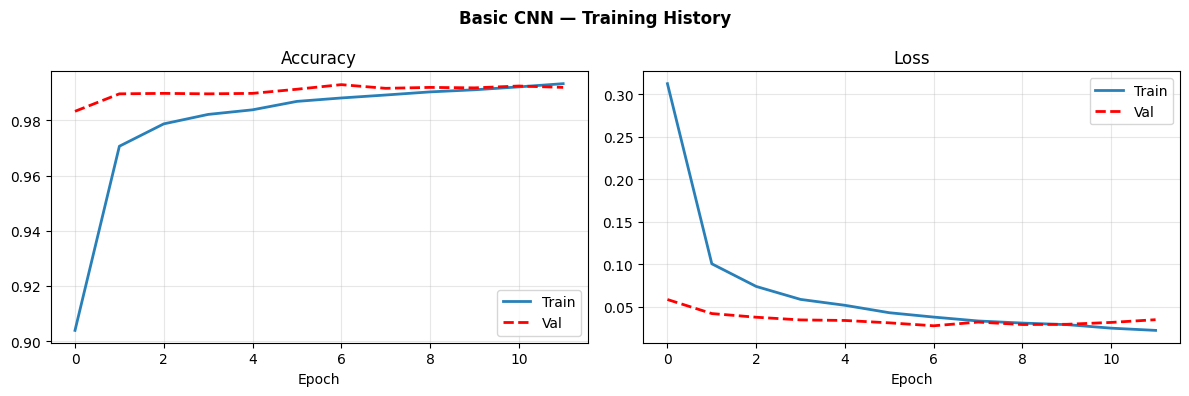

  Best Val Accuracy: 99.30%

─────────────────────────────────────────────
  Basic CNN
  Test Accuracy : 99.17%
─────────────────────────────────────────────
              precision    recall  f1-score   support

           0      0.988     0.998     0.993       980
           1      0.996     0.997     0.997      1135
           2      0.983     0.997     0.990      1032
           3      0.993     0.994     0.994      1010
           4      0.997     0.994     0.995       982
           5      0.984     0.992     0.988       892
           6      0.998     0.985     0.992       958
           7      0.997     0.982     0.990      1028
           8      0.990     0.992     0.991       974
           9      0.990     0.984     0.987      1009

    accuracy                          0.992     10000
   macro avg      0.992     0.992     0.992     10000
weighted avg      0.992     0.992     0.992     10000



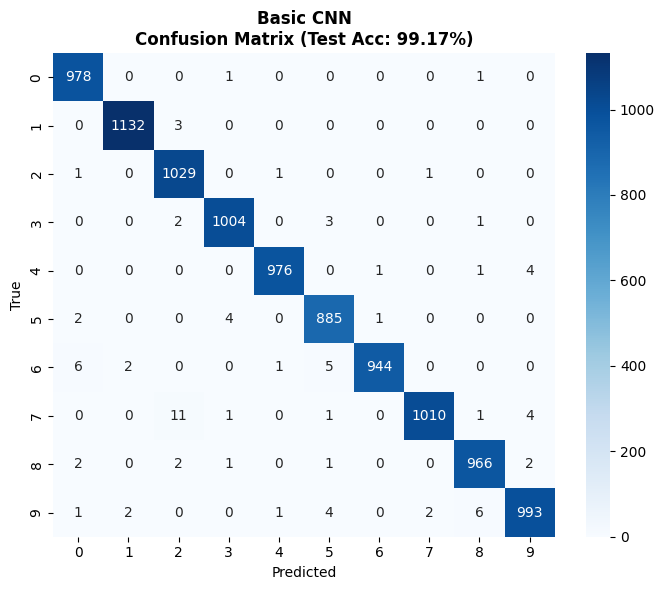

In [13]:
plot_history(history2, 'Basic CNN', '#2980b9')
acc2 = evaluate_model(model2, X_test_cnn, y_test_oh, 'Basic CNN')


## 7. Model 3 — Improved CNN with BatchNorm + Dropout

Enhances the basic CNN with **Batch Normalization** (stabilizes training) and more aggressive **Dropout** (reduces overfitting).



In [14]:
def build_improved_cnn():
    inp = keras.Input(shape=(28, 28, 1))

    x = layers.Conv2D(32, (3,3), padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)

    out = layers.Dense(10, activation='softmax')(x)
    return keras.Model(inp, out, name='Improved_CNN')

model3 = build_improved_cnn()
model3.summary()


Model: "Improved_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,703,050 (6.50 MB)

 Trainable params: 1,702,090 (6.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [15]:
model3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history3 = model3.fit(
    X_train_cnn, y_train_oh,
    epochs=30, batch_size=128,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True, verbose=1)],
    verbose=1
)


Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.9378 - loss: 0.2019 - val_accuracy: 0.4983 - val_loss: 1.7394
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9776 - loss: 0.0747 - val_accuracy: 0.9855 - val_loss: 0.0443
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9817 - loss: 0.0585 - val_accuracy: 0.9900 - val_loss: 0.0303
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9850 - loss: 0.0484 - val_accuracy: 0.9922 - val_loss: 0.0254
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9870 - loss: 0.0412 - val_accuracy: 0.9925 - val_loss: 0.0286
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9875 - loss: 0.0385 - val_accuracy: 0.9917 - val_loss: 0.0286
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9888 - loss: 0.0362 - val_accuracy: 0.9925 - val_loss: 0.0245
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9895 - loss: 0.0323 - val_accuracy: 

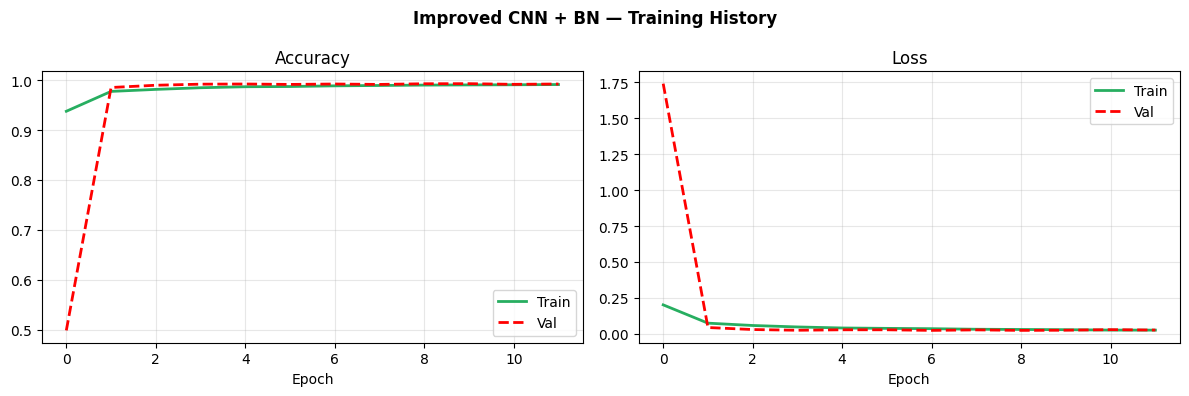

  Best Val Accuracy: 99.32%

─────────────────────────────────────────────
  Improved CNN + BN
  Test Accuracy : 99.35%
─────────────────────────────────────────────
              precision    recall  f1-score   support

           0      0.995     0.996     0.995       980
           1      0.996     0.999     0.997      1135
           2      0.996     0.994     0.995      1032
           3      0.995     0.996     0.996      1010
           4      0.997     0.987     0.992       982
           5      0.993     0.992     0.993       892
           6      0.989     0.995     0.992       958
           7      0.993     0.988     0.991      1028
           8      0.990     0.997     0.993       974
           9      0.991     0.990     0.991      1009

    accuracy                          0.994     10000
   macro avg      0.993     0.993     0.993     10000
weighted avg      0.994     0.994     0.993     10000



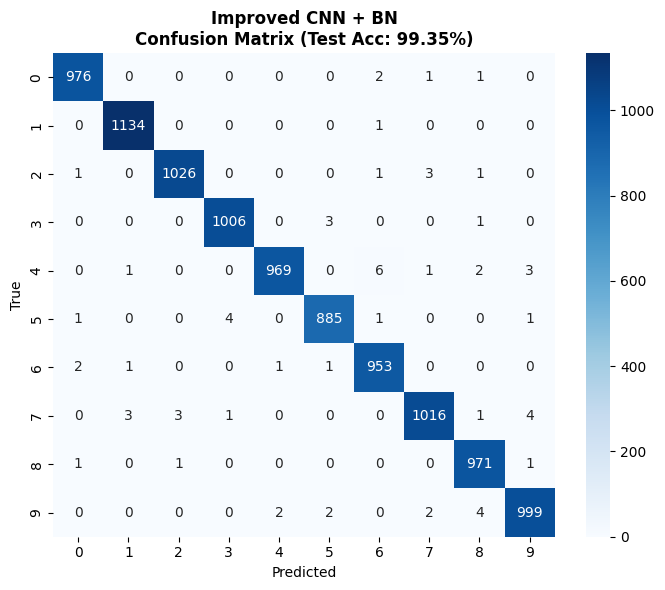

In [16]:
plot_history(history3, 'Improved CNN + BN', '#27ae60')
acc3 = evaluate_model(model3, X_test_cnn, y_test_oh, 'Improved CNN + BN')


## 8. Model Comparison

In [17]:
model_names = ['ANN', 'Basic CNN', 'Improved CNN + BN']
accuracies  = [acc1 * 100, acc2 * 100, acc3 * 100]
params      = [model1.count_params(), model2.count_params(), model3.count_params()]

print("\n" + "="*50)
print(f"  {'Model':<22} {'Accuracy':>10}  {'Params':>10}")
print("="*50)
for name, acc, p in zip(model_names, accuracies, params):
    print(f"  {name:<22} {acc:>9.2f}%  {p:>10,}")
print("="*50)



  Model                    Accuracy      Params
  ANN                        98.35%     235,146
  Basic CNN                  99.17%     421,642
  Improved CNN + BN          99.35%   1,703,050


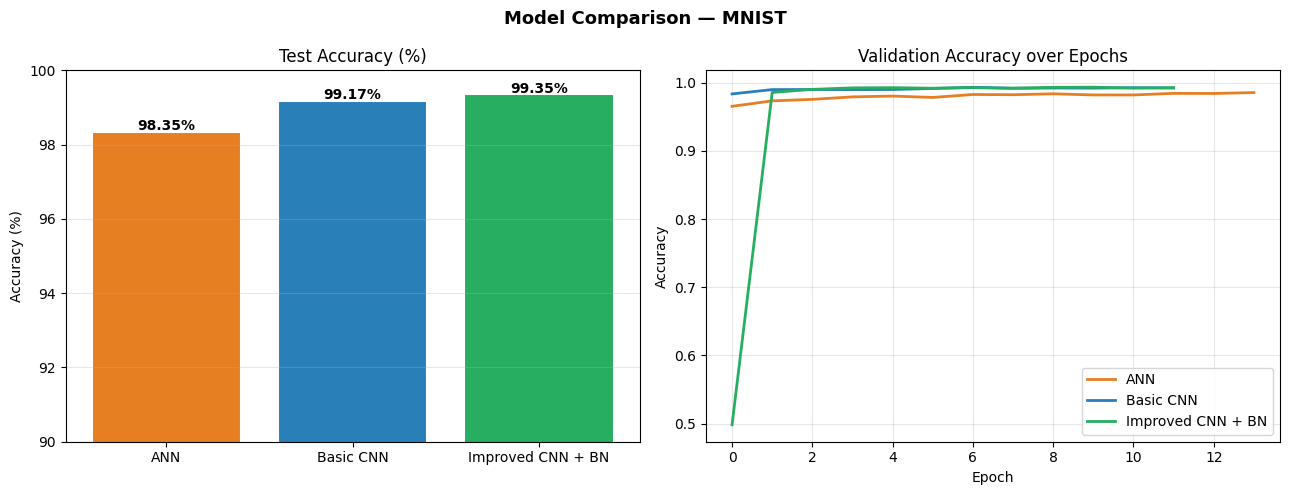

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Comparison — MNIST', fontsize=13, fontweight='bold')

colors = ['#e67e22', '#2980b9', '#27ae60']

bars = axes[0].bar(model_names, accuracies, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_ylim(90, 100)
axes[0].set_title('Test Accuracy (%)')
axes[0].set_ylabel('Accuracy (%)')
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}%', ha='center', fontweight='bold', fontsize=10)

model_histories = [
    (history1, 'ANN', '#e67e22'),
    (history2, 'Basic CNN', '#2980b9'),
    (history3, 'Improved CNN + BN', '#27ae60')
]
for hist, label, color in model_histories:
    axes[1].plot(hist.history['val_accuracy'], color=color, lw=2, label=label)
axes[1].set_title('Validation Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('comparison.png', dpi=120, bbox_inches='tight')
plt.show()


Misclassified by Improved CNN: 65 / 10000 images


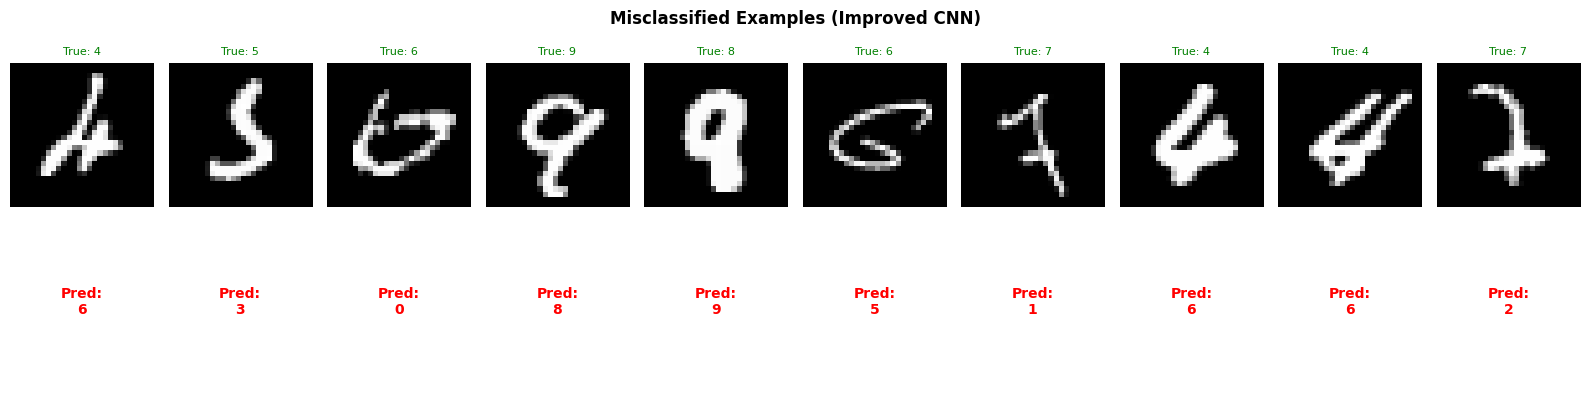

In [19]:
y_pred3 = np.argmax(model3.predict(X_test_cnn, verbose=0), axis=1)
wrong_idx = np.where(y_pred3 != y_test)[0]

print(f"Misclassified by Improved CNN: {len(wrong_idx)} / {len(y_test)} images")

fig, axes = plt.subplots(2, 10, figsize=(16, 4))
fig.suptitle("Misclassified Examples (Improved CNN)", fontsize=12, fontweight='bold')

for col, idx in enumerate(wrong_idx[:10]):
    axes[0, col].imshow(X_test[idx], cmap='gray')
    axes[0, col].axis('off')
    axes[0, col].set_title(f'True: {y_test[idx]}', color='green', fontsize=8)
    axes[1, col].text(0.5, 0.5, f'Pred:\n{y_pred3[idx]}',
                      transform=axes[1, col].transAxes,
                      ha='center', va='center', fontsize=10, color='red',
                      fontweight='bold')
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig('misclassified.png', dpi=120, bbox_inches='tight')
plt.show()


## 9. Conclusion

**Observations:**
- Even a simple ANN achieves ~97.5% — MNIST is a relatively easy dataset
- Adding convolutional layers (CNN) pushes accuracy to ~99% by learning local patterns like edges and curves
- Batch Normalization speeds up convergence and makes training more stable, while Dropout prevents overfitting
- The Improved CNN misclassifies fewer than 70 images out of 10,000

**When does ANN fail?** The ANN treats each pixel independently — it cannot detect that "an edge at position (5,5)" and "the same edge at position (6,5)" are the same feature. CNNs solve this through weight sharing and pooling.
